In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from scripts.calc_tepl import Tepl

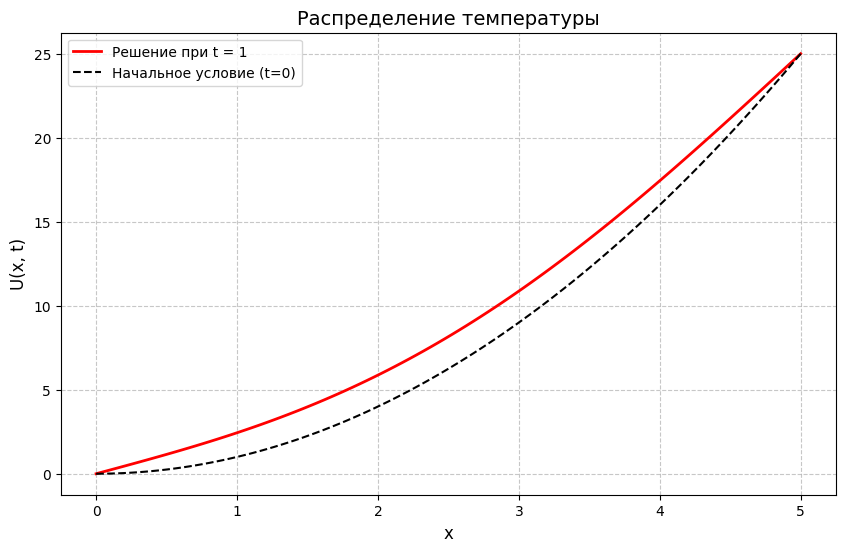

In [6]:
model = Tepl(a=1.0, x1=0.0, x2=5.0, t=1)
model.set_initial_condition(B=1.0, Nx=100)  
model.calc_temp(Nt=1000)  
model.plot_solution(B=1.0) 

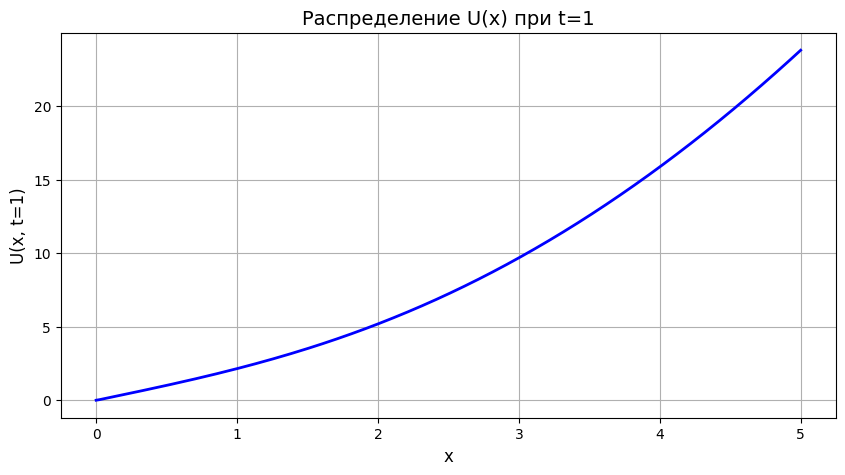

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

a = 1.0
B = 1.0

# Решение ОДУ
def ode_system(z, y):
    f, fp = y
    df_dz = fp
    dfp_dz = -fp * (4/z + 0.5*z) - (2/(z**2)) * f
    return [df_dz, dfp_dz]

z_max, z_min = 0.01, 10
z_eval = np.linspace(z_max, z_min, 1000)
sol = solve_ivp(ode_system, [z_max, z_min], [1.0, 0.0], t_eval=z_eval)

# [1.0, 0.0] - нач условия
f_interp = interp1d(sol.t[::-1], sol.y[0][::-1], kind='cubic', fill_value="extrapolate")

# kind='cubic' —  кубическая интерполяция 

# fill_value="extrapolate" — разрешаешь экстраполяцию 
# если z выйдет за границы решённого интервала, то интерполяция всё равно даст значение)

# Фиксируем время t и строим U(x)
t_fixed = 1
x_vals = np.linspace(0, 5, 200)
z_vals = x_vals / (a * np.sqrt(t_fixed))
U_vals = B * x_vals**2 * f_interp(z_vals)

plt.figure(figsize=(10, 5))
plt.plot(x_vals, U_vals*100, 'b-', linewidth=2)
plt.xlabel('x', fontsize=12)
plt.ylabel(f'U(x, t={t_fixed})', fontsize=12)
plt.title(f'Распределение U(x) при t={t_fixed}', fontsize=14)
plt.grid(True)
plt.show()